<a href="https://colab.research.google.com/github/KedaarK/ML-Experiments-D17A/blob/main/Batch_A/Exp_5_Kernel_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SVM (Support Vector Machine)**
**Primary Objective of SVM:**
* **Find Optimal Hyperplane**: To find the hyperplane that best separates data points of different classes.

* **Maximize Margin**: Maximize the margin (distance) between the hyperplane and the nearest data points from each class for better generalization and robustness.

**Support Vectors:**
* **Definition**: Support vectors are the data points closest to the decision boundary (hyperplane).

* **Importance**: They define the position and orientation of the hyperplane since the margin depends on their location; all other points don't influence the boundary directly.

# **Kernel SVM**
It is a type of Support Vector Machine that uses **kernel functions** to implicitly **map input data into a higher-dimensional feature space**. This mapping allows the SVM to find a linear separating hyperplane in that space, enabling it to handle **non-linearly separable data** effectively without explicitly transforming the data.

**Kernel Trick**
* **What It Is:** A method that uses kernel functions to implicitly map input data into a higher-dimensional feature space without explicitly computing the transformation.

* **Why Essential:** It enables SVMs to solve non-linear classification problems by making data linearly separable in this higher-dimensional space.

**Dimensionality and Kernel Trick**
* **Implicit Mapping:** The SVM does not explicitly map data into the higher dimension; instead, the kernel function computes inner products in that space directly, saving computation.

**Role of the C Hyperparameter**
* **Function:** Controls the trade-off between maximizing the margin and minimizing classification errors (slack).

* **Effect of Large C:** A large C places a higher penalty on misclassification errors, forcing the model to fit the training data more strictly, reducing tolerance for misclassification and potentially causing overfitting.

# Step 1: Load Data and Initial Preprocessing

It handles the loading of the CSV file and performs basic Exploratory Data Analysis (EDA) to check the dataset's structure, size, and integrity.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                            recall_score, f1_score, roc_auc_score, roc_curve)
from sklearn.decomposition import PCA
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# File upload section
print("Please upload your wine quality CSV file")
print("If running in Google Colab, use the file upload widget")
print("If running locally, make sure the CSV file is in the correct path")

# For Google Colab file upload
try:
    from google.colab import files
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    dataset = pd.read_csv(filename)
    print(f"File '{filename}' uploaded successfully!")
except ImportError:
    # For local execution - modify the path as needed
    file_path = input("Enter the path to your wine quality CSV file (or press Enter for 'WineQT.csv'): ")
    if file_path == "":
        file_path = 'WineQT.csv'
    dataset = pd.read_csv(file_path)
    print(f"Dataset loaded from '{file_path}'")

# Display basic information about the dataset
print("\nDataset Info:")
print(f"Shape: {dataset.shape}")
print(f"Columns: {list(dataset.columns)}")
print("\nFirst 5 rows:")
print(dataset.head())

print("\nDataset Statistics:")
print(dataset.describe())

# Check for missing values
print(f"\nMissing values: {dataset.isnull().sum().sum()}")

Please upload your wine quality CSV file
If running in Google Colab, use the file upload widget
If running locally, make sure the CSV file is in the correct path


Saving WineQT.csv to WineQT.csv
File 'WineQT.csv' uploaded successfully!

Dataset Info:
Shape: (1143, 13)
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

First 5 rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20     

# Step 2: Data Preparation, Scaling, and Dimensionality Reduction (PCA)

It converts the multi-class quality rating into a **binary target** and splits the data. It then applies **Standard Scaling** to the features and uses **PCA** to reduce the dimensionality to 2 components for later visualization.

In [ ]:
# Prepare the data
# Remove 'Id' column if it exists
if 'Id' in dataset.columns:
    dataset = dataset.drop('Id', axis=1)

# Separate features and target
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Unique target values: {np.unique(y)}")

# For multi-class classification, we'll convert to binary classification
# (Quality >= 6 = Good wine, Quality < 6 = Average wine)
y_binary = (y >= 6).astype(int)
print(f"Binary target distribution: {np.bincount(y_binary)}")

# Split the dataset with same random state for consistency
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.25, random_state=0)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

# Feature scaling
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

# For visualization, we need to reduce dimensions to 2D using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")


Features shape: (1143, 11)
Target shape: (1143,)
Unique target values: [3 4 5 6 7 8]
Binary target distribution: [522 621]

Training set shape: (857, 11)
Test set shape: (286, 11)
PCA explained variance ratio: [0.28561711 0.17800692]
Total variance explained: 0.4636


# Step 3: Train and Evaluate SVM Models (Kernel Comparison)
It iterates through the three defined SVM kernels (**linear, rbf, sigmoid**). For each kernel, it trains a classifier on the full scaled data, calculates various **performance metrics** (**Accuracy, F1, AUC**, etc.) and stores the results for comparison.

**Non-linearity:**
*   **Best Kernel for Complex Boundaries**: The **RBF kernel** is best suited for complex, non-linear decision boundaries because it can map data to an infinite-dimensional space allowing flexible decision surfaces.

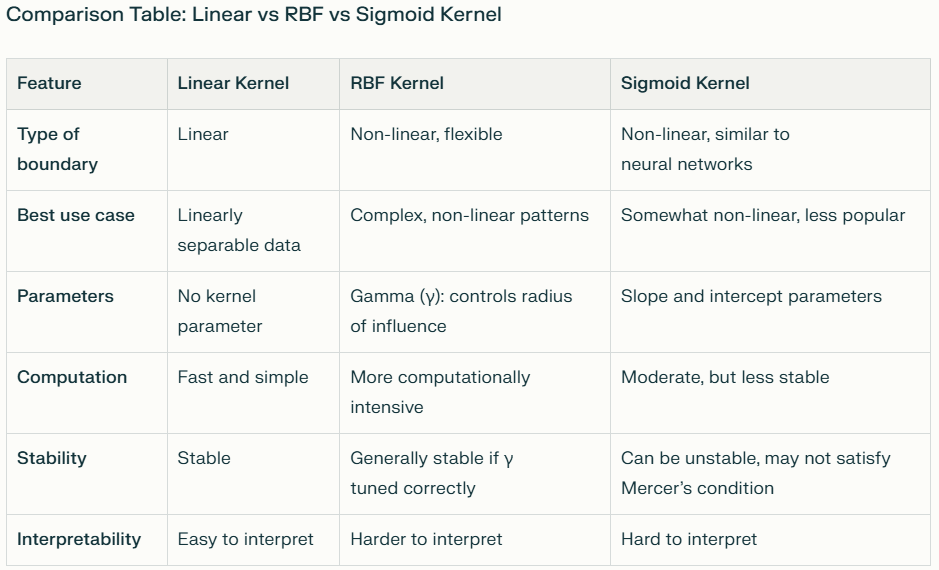

In [ ]:
# Define kernels to compare
kernels = ['linear', 'rbf', 'sigmoid']
results = {}
classifiers = {}

print("\nTraining SVM models with different kernels...")

# Train and evaluate each kernel
for kernel in kernels:
    print(f"\nTraining SVM with {kernel} kernel...")

    # Create and train the classifier on original scaled data
    classifier = SVC(kernel=kernel, random_state=0, probability=True)
    classifier.fit(X_train_scaled, y_train)

    # Also train on PCA data for visualization
    classifier_pca = SVC(kernel=kernel, random_state=0, probability=True)
    classifier_pca.fit(X_train_pca, y_train)

    # Make predictions on original data
    y_pred = classifier.predict(X_test_scaled)
    y_pred_proba = classifier.predict_proba(X_test_scaled)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_pred_proba)
    cm = confusion_matrix(y_test, y_pred)

    # Store results
    results[kernel] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc': auc,
        'confusion_matrix': cm,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

    # Store classifiers for visualization
    classifiers[kernel] = classifier_pca

    print(f"{kernel.upper()} Kernel Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC: {auc:.4f}")


Training SVM models with different kernels...

Training SVM with linear kernel...
LINEAR Kernel Results:
Accuracy: 0.7727
Precision: 0.7947
Recall: 0.7792
F1-Score: 0.7869
AUC: 0.8563

Training SVM with rbf kernel...
RBF Kernel Results:
Accuracy: 0.7867
Precision: 0.7784
Recall: 0.8442
F1-Score: 0.8100
AUC: 0.8737

Training SVM with sigmoid kernel...
SIGMOID Kernel Results:
Accuracy: 0.7063
Precision: 0.7574
Recall: 0.6688
F1-Score: 0.7103
AUC: 0.7740


# Step 4: Generate Comparison Table and Find Best Kernel

The calculated metrics for all kernels are aggregated into a comparison DataFrame. The code then uses the **AUC score (Area Under the ROC Curve)** as the primary metric to determine and print the best-performing kernel.

In [ ]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Kernel': kernels,
    'Accuracy': [results[k]['accuracy'] for k in kernels],
    'Precision': [results[k]['precision'] for k in kernels],
    'Recall': [results[k]['recall'] for k in kernels],
    'F1-Score': [results[k]['f1_score'] for k in kernels],
    'AUC': [results[k]['auc'] for k in kernels]
})

print("\n" + "="*60)
print("KERNEL COMPARISON TABLE")
print("="*60)
print(comparison_df.round(4))

# Find best performing kernel
best_kernel = comparison_df.loc[comparison_df['AUC'].idxmax(), 'Kernel']
print(f"\nBest performing kernel (by AUC): {best_kernel.upper()}")


KERNEL COMPARISON TABLE
    Kernel  Accuracy  Precision  Recall  F1-Score     AUC
0   linear    0.7727     0.7947  0.7792    0.7869  0.8563
1      rbf    0.7867     0.7784  0.8442    0.8100  0.8737
2  sigmoid    0.7063     0.7574  0.6688    0.7103  0.7740

Best performing kernel (by AUC): RBF


# Step 5: Visualize Decision Boundaries, ROC Curves, and Performance

It plots **decision boundaries** (using the PCA-reduced data), **ROC curves** to compare AUC scores, and **bar plots** to visually rank the kernels across all metrics.



Generating Decision Boundary Visualizations...


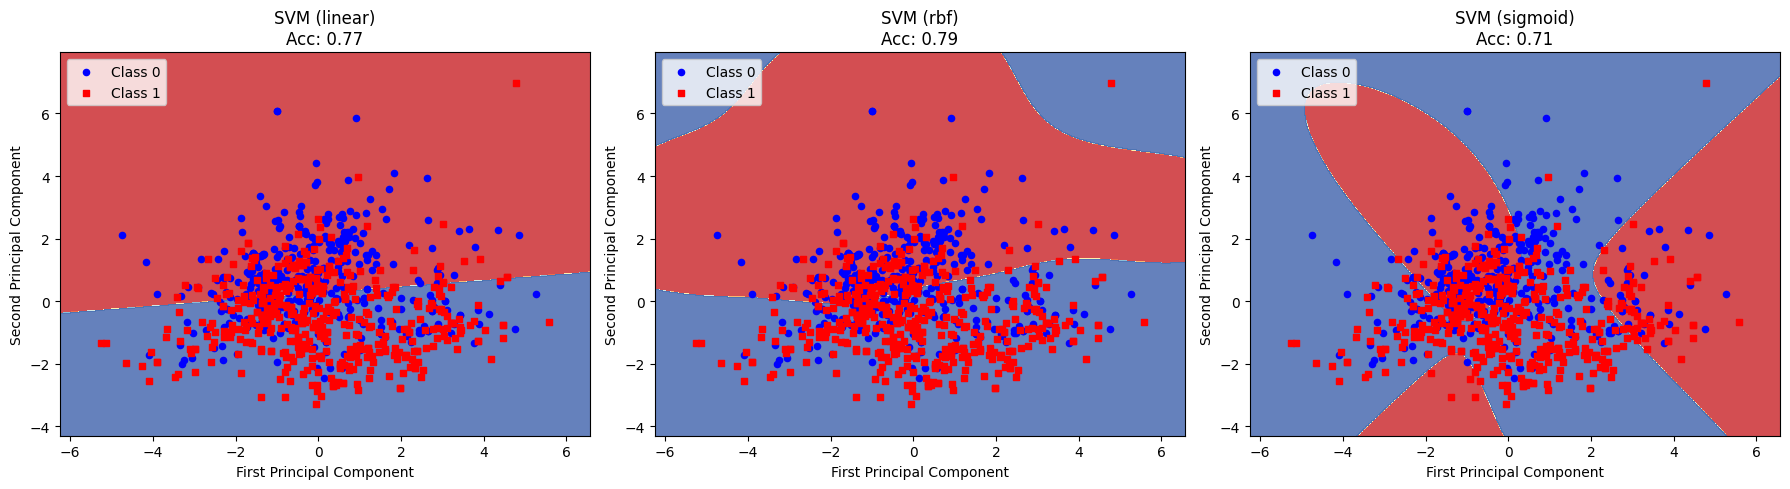

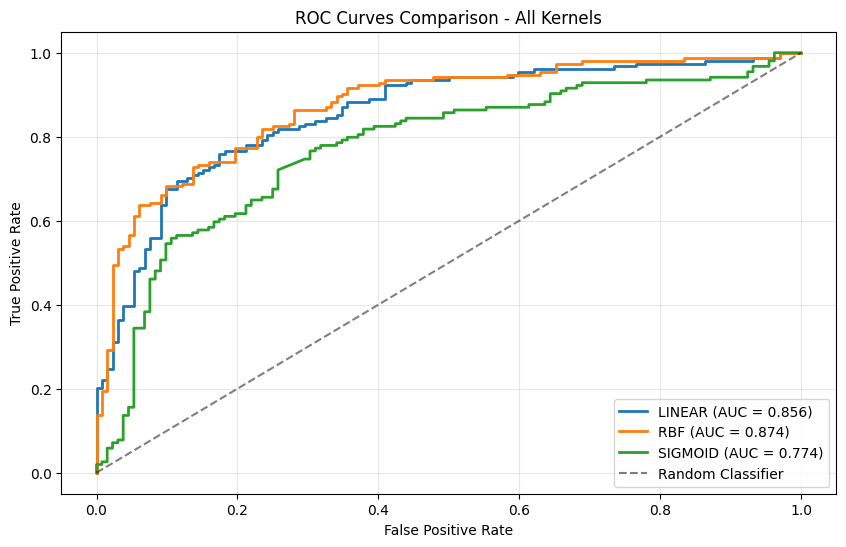

In [ ]:
# Decision Boundary Visualization (like your teacher's example)
def plot_decision_boundary(classifier, X_data, y_data, title, kernel_name):
    """Plot decision boundary for 2D data"""
    h = 0.02  # step size in the mesh

    # Create a mesh
    x_min, x_max = X_data[:, 0].min() - 1, X_data[:, 0].max() + 1
    y_min, y_max = X_data[:, 1].min() - 1, X_data[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Make predictions on the mesh
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    Z = classifier.predict(mesh_points)
    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

    # Plot the data points
    scatter = plt.scatter(X_data[:, 0], X_data[:, 1], c=y_data, cmap=plt.cm.RdYlBu, edgecolors='black')
    plt.colorbar(scatter)
    plt.title(f'{title}\nAcc: {results[kernel_name]["accuracy"]:.2f}')
    plt.xlabel('First Principal Component')
    plt.ylabel('Second Principal Component')
    plt.show()

# Create decision boundary plots for all kernels
print("\nGenerating Decision Boundary Visualizations...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, kernel in enumerate(kernels):
    ax = axes[i]
    classifier = classifiers[kernel]

    # Create mesh for decision boundary
    h = 0.02
    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Make predictions on the mesh
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    Z = classifier.predict(mesh_points)
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)

    # Plot data points
    class_0 = X_train_pca[y_train == 0]
    class_1 = X_train_pca[y_train == 1]

    ax.scatter(class_0[:, 0], class_0[:, 1], c='blue', marker='o', label='Class 0', s=20)
    ax.scatter(class_1[:, 0], class_1[:, 1], c='red', marker='s', label='Class 1', s=20)

    ax.set_title(f'SVM ({kernel})\nAcc: {results[kernel]["accuracy"]:.2f}')
    ax.set_xlabel('First Principal Component')
    ax.set_ylabel('Second Principal Component')
    ax.legend()

plt.tight_layout()
plt.show()

# ROC Curves Comparison
plt.figure(figsize=(10, 6))
for kernel in kernels:
    fpr, tpr, _ = roc_curve(y_test, results[kernel]['y_pred_proba'])
    auc_score = results[kernel]['auc']
    plt.plot(fpr, tpr, label=f'{kernel.upper()} (AUC = {auc_score:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison - All Kernels')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Step 6: Final Summary Report and Export



In [ ]:
# Summary Report
print("\n" + "="*60)
print("DETAILED PERFORMANCE REPORT")
print("="*60)

for kernel in kernels:
    print(f"\n{kernel.upper()} KERNEL:")
    print(f"  Accuracy:  {results[kernel]['accuracy']:.4f}")
    print(f"  Precision: {results[kernel]['precision']:.4f}")
    print(f"  Recall:    {results[kernel]['recall']:.4f}")
    print(f"  F1-Score:  {results[kernel]['f1_score']:.4f}")
    print(f"  AUC:       {results[kernel]['auc']:.4f}")

    cm = results[kernel]['confusion_matrix']
    tn, fp, fn, tp = cm.ravel()
    print(f"  Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

print(f"\nRECOMMENDATION:")
print(f"Based on AUC score, the {best_kernel.upper()} kernel performs best for this wine quality dataset.")

# Create and display formatted comparison table (like your teacher's format)
print("\n" + "="*65)
print("KERNEL COMPARISON TABLE")
print("="*65)
print(f"{'Kernel':<10} {'Accuracy':<10} {'Precision':<11} {'Recall':<10} {'F1-Score':<10} {'AUC':<10}")
print("-" * 65)
for i, kernel in enumerate(kernels):
    print(f"{i:<1} {kernel:<9} {results[kernel]['accuracy']:<10.4f} "
          f"{results[kernel]['precision']:<11.4f} {results[kernel]['recall']:<10.4f} "
          f"{results[kernel]['f1_score']:<10.4f} {results[kernel]['auc']:<10.4f}")

# Save results to CSV
comparison_df.to_csv('kernel_comparison_results.csv', index=False)
print(f"\nComparison results saved to 'kernel_comparison_results.csv'")

# Additional insights
print("\n" + "="*60)
print("MODEL INSIGHTS")
print("="*60)
print(f"Dataset contains {len(dataset)} wine samples")
print(f"Number of features: {X.shape[1]}")
print(f"Class distribution: {dict(zip(*np.unique(y_binary, return_counts=True)))}")
print(f"PCA captured {pca.explained_variance_ratio_.sum():.2%} of total variance in 2 components")

# Performance ranking
ranking = comparison_df.sort_values('AUC', ascending=False)
print(f"\nKernel Performance Ranking (by AUC):")
for i, (idx, row) in enumerate(ranking.iterrows(), 1):
    print(f"{i}. {row['Kernel'].upper()}: AUC = {row['AUC']:.4f}")



DETAILED PERFORMANCE REPORT

LINEAR KERNEL:
  Accuracy:  0.7727
  Precision: 0.7947
  Recall:    0.7792
  F1-Score:  0.7869
  AUC:       0.8563
  Confusion Matrix: TN=101, FP=31, FN=34, TP=120

RBF KERNEL:
  Accuracy:  0.7867
  Precision: 0.7784
  Recall:    0.8442
  F1-Score:  0.8100
  AUC:       0.8737
  Confusion Matrix: TN=95, FP=37, FN=24, TP=130

SIGMOID KERNEL:
  Accuracy:  0.7063
  Precision: 0.7574
  Recall:    0.6688
  F1-Score:  0.7103
  AUC:       0.7740
  Confusion Matrix: TN=99, FP=33, FN=51, TP=103

RECOMMENDATION:
Based on AUC score, the RBF kernel performs best for this wine quality dataset.

KERNEL COMPARISON TABLE
Kernel     Accuracy   Precision   Recall     F1-Score   AUC       
-----------------------------------------------------------------
0 linear    0.7727     0.7947      0.7792     0.7869     0.8563    
1 rbf       0.7867     0.7784      0.8442     0.8100     0.8737    
2 sigmoid   0.7063     0.7574      0.6688     0.7103     0.7740    

Comparison results s